In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('train.csv')
display(df.head())

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


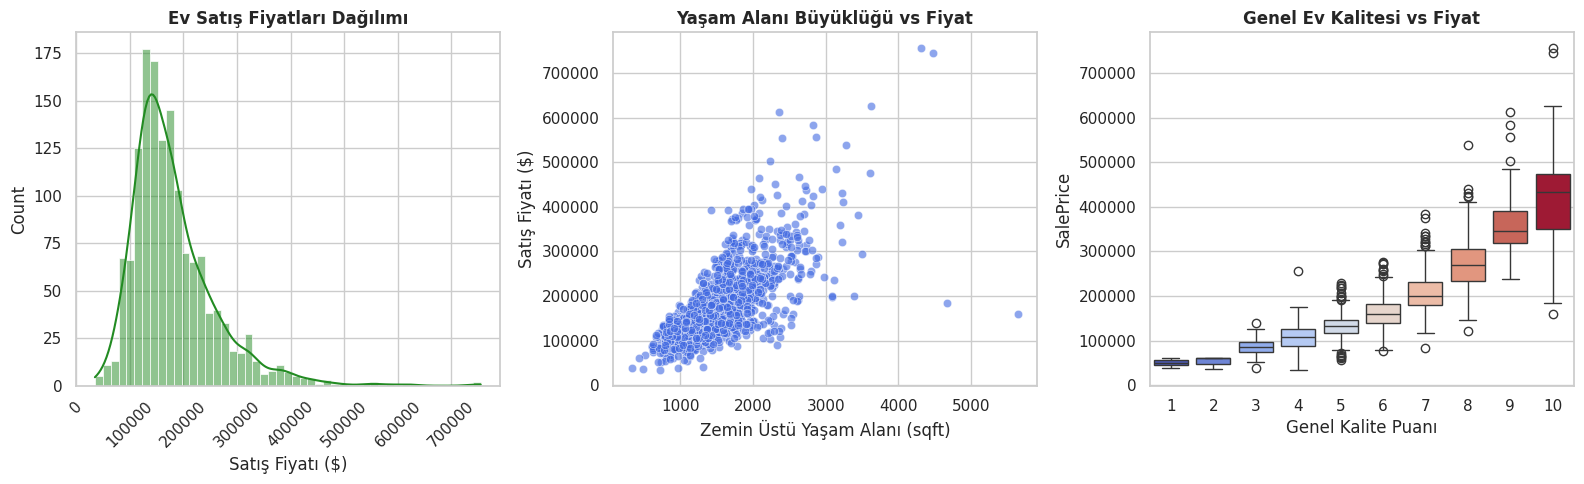

In [ ]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(16, 5))
plt.subplot(1, 3, 1)
sns.histplot(df['SalePrice'], kde=True, color='forestgreen')
plt.title('Ev Satış Fiyatları Dağılımı', fontweight='bold')
plt.xlabel('Satış Fiyatı ($)')
plt.xticks(rotation=45)

plt.subplot(1, 3, 2)
sns.scatterplot(x=df['GrLivArea'], y=df['SalePrice'], color='royalblue', alpha=0.6)
plt.title('Yaşam Alanı Büyüklüğü vs Fiyat', fontweight='bold')
plt.xlabel('Zemin Üstü Yaşam Alanı (sqft)')
plt.ylabel('Satış Fiyatı ($)')

plt.subplot(1, 3, 3)
sns.boxplot(x='OverallQual', y='SalePrice', hue='OverallQual', data=df, palette='coolwarm', legend=False)
plt.title('Genel Ev Kalitesi vs Fiyat', fontweight='bold')
plt.xlabel('Genel Kalite Puanı')

plt.tight_layout()
plt.show()

In [ ]:
df_temiz = df.drop(['Alley', 'PoolQC', 'Fence', 'MiscFeature', 'Id'], axis=1)

sayisal_sutunlar = df_temiz.select_dtypes(include=['int64', 'float64']).columns
metin_sutunlar = df_temiz.select_dtypes(include=['object']).columns

for col in sayisal_sutunlar:
    df_temiz[col] = df_temiz[col].fillna(df_temiz[col].median())

for col in metin_sutunlar:
    df_temiz[col] = df_temiz[col].fillna(df_temiz[col].mode()[0])

df_temiz = pd.get_dummies(df_temiz, drop_first=True)
print(f"Modelin öğreneceği toplam özellik sayısı: {df_temiz.shape[1]}")

Modelin öğreneceği toplam özellik sayısı: 236


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

X = df_temiz.drop('SalePrice', axis=1)
y = df_temiz['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

tahminler = model.predict(X_test)
mae = mean_absolute_error(y_test, tahminler)
r2 = r2_score(y_test, tahminler)

print(f"Ortalama Mutlak Hata: {mae:,.2f} $")
print(f"R2: {r2:.4f}")

Ortalama Mutlak Hata: 17,453.89 $
R2: 0.8921


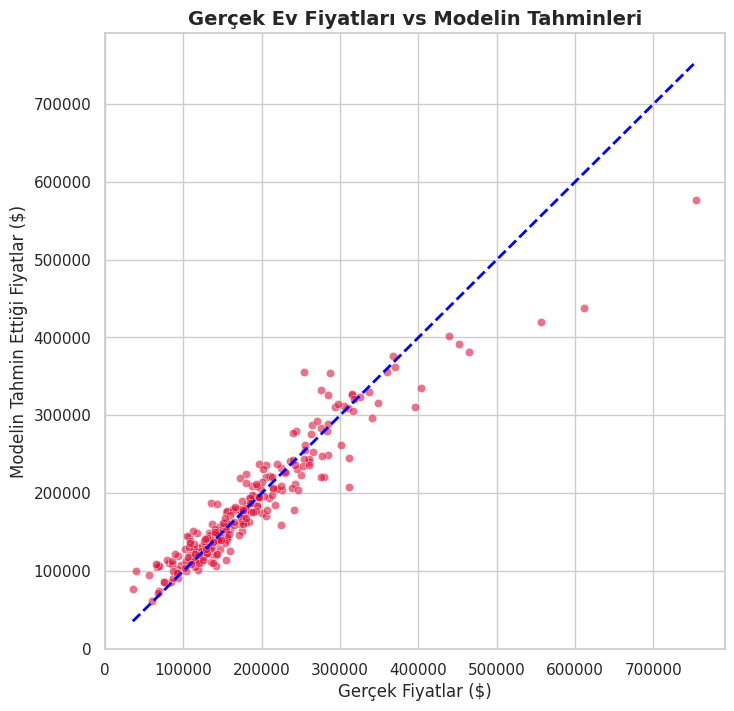

In [ ]:
plt.figure(figsize=(8, 8))

sns.scatterplot(x=y_test, y=tahminler, color='crimson', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='blue', linestyle='--', linewidth=2)
plt.title('Gerçek Ev Fiyatları vs Modelin Tahminleri', fontsize=14, fontweight='bold')
plt.xlabel('Gerçek Fiyatlar ($)', fontsize=12)
plt.ylabel('Modelin Tahmin Ettiği Fiyatlar ($)', fontsize=12)

plt.show()